# Pre-processing
Pre-processing the Irish Coast Buoy Networks (ICBN) for STGNN

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datetime import datetime
import folium

In [2]:
root_path = '../../experiments'
df = pd.read_csv(f'{root_path}/data/raw/waves.csv')

In [3]:
df.drop(index=0, inplace=True)
df = df.reset_index(drop=True)
df.drop(columns=['index'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3465 entries, 0 to 3464
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   time                              3465 non-null   object
 1   longitude                         3465 non-null   object
 2   latitude                          3465 non-null   object
 3   stationID                         3465 non-null   object
 4   significant_wave_height           3465 non-null   object
 5   mean_wave_period                  3465 non-null   object
 6   mean_wave_direction               3465 non-null   object
 7   wave_power_per_unit_crest_length  3465 non-null   object
 8   peak_period                       3465 non-null   object
 9   energy_period                     3465 non-null   object
dtypes: object(10)
memory usage: 270.8+ KB


In [4]:
df[['longitude', 'latitude','significant_wave_height',
       'mean_wave_period', 'mean_wave_direction',
       'wave_power_per_unit_crest_length', 'peak_period', 'energy_period']]=df[['longitude', 'latitude','significant_wave_height',
       'mean_wave_period', 'mean_wave_direction',
       'wave_power_per_unit_crest_length', 'peak_period', 'energy_period']].astype(float)
       
df['time'] = pd.to_datetime(df['time'])

In [5]:
station_positions = df.groupby(['latitude', 'longitude',"stationID"]).size().reset_index().rename(columns={0: 'count'})
station_positions

,latitude,longitude,stationID,count
0,51.21660,-10.55000,M3,385
1,51.69000,-6.70400,M5,385
2,51.76833,-8.23530,Cork,385
3,53.06050,-15.93000,M6,385
4,53.22700,-9.27100,Spiddal,385
5,53.48000,-5.42500,M2,385
6,54.23086,-10.14618,Belmullet_Inner,385
7,54.28150,-10.27830,Belmullet_Outer,385
8,55.00000,-10.00000,M4,385


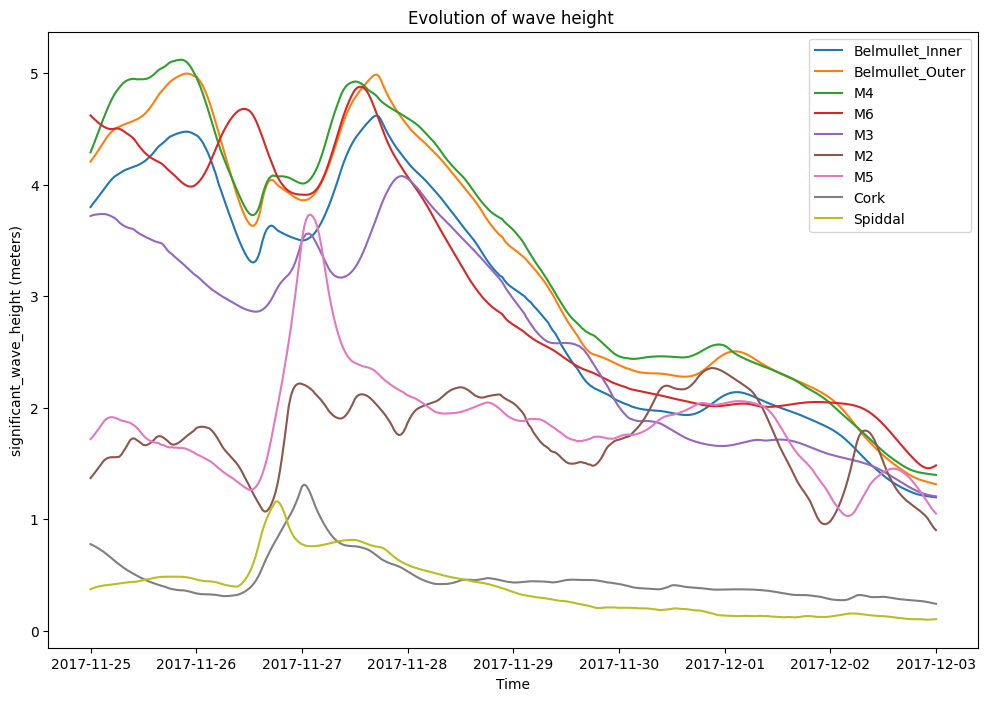

In [6]:
plt.figure(figsize=(12, 8))
color_cyc=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']
stations=['Belmullet_Inner','Belmullet_Outer','M4','M6','M3','M2','M5','Cork','Spiddal']
for i,station in enumerate (stations):
    df1=df[df["stationID"]==station]
    plt.plot(df1['time'], df1['significant_wave_height'],label=station,color=color_cyc[i])

plt.xlabel('Time')
plt.ylabel('significant_wave_height (meters)')
plt.title('Evolution of wave height ')
plt.legend()

plt.show()

### Turning the data into torch tensors for TSL

In [7]:
station_groups = {station: group.drop("stationID", axis=1).sort_values('time') for station, group in df.groupby('stationID')}
station_groups['Belmullet_Inner'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 385 entries, 0 to 384
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   time                              385 non-null    datetime64[ns, UTC]
 1   longitude                         385 non-null    float64            
 2   latitude                          385 non-null    float64            
 3   significant_wave_height           385 non-null    float64            
 4   mean_wave_period                  385 non-null    float64            
 5   mean_wave_direction               385 non-null    float64            
 6   wave_power_per_unit_crest_length  385 non-null    float64            
 7   peak_period                       385 non-null    float64            
 8   energy_period                     385 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(8)
memory usage: 30.1 KB


In [8]:
time = station_groups['Belmullet_Inner']['time']

year = time.dt.year
month = time.dt.month
day = time.dt.day
hour = time.dt.hour

month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
day_sin = np.sin(2 * np.pi * day / 31)
day_cos = np.cos(2 * np.pi * day / 31)
hour_sin = np.sin(2 * np.pi * hour / 24)
hour_cos = np.cos(2 * np.pi * hour / 24)

month_sin_tensor = torch.tensor(month_sin.values, dtype=torch.float32)
month_cos_tensor = torch.tensor(month_cos.values, dtype=torch.float32)
day_sin_tensor = torch.tensor(day_sin.values, dtype=torch.float32)
day_cos_tensor = torch.tensor(day_cos.values, dtype=torch.float32)
hour_sin_tensor = torch.tensor(hour_sin.values, dtype=torch.float32)
hour_cos_tensor = torch.tensor(hour_cos.values, dtype=torch.float32)

In [9]:
time_tensor = torch.stack([month_sin_tensor, month_cos_tensor, day_sin_tensor, day_cos_tensor, hour_sin_tensor, hour_cos_tensor], dim=1)

In [10]:
target_tensors = []
data_tensors = []
for station, df in station_groups.items():
    target_tensors.append(torch.tensor(df['significant_wave_height'].values, dtype=torch.float32).unsqueeze(1))
    data_tensors.append(torch.cat((torch.tensor(df.drop(columns=['time', 'longitude', 'latitude'], axis=1).values, dtype=torch.float32), time_tensor), dim=1))

data_tensors = torch.stack(data_tensors, dim=1)
target_tensors = torch.stack(target_tensors, dim=1)

In [11]:
data_tensors.shape, target_tensors.shape, time_tensor.shape

(torch.Size([385, 9, 12]), torch.Size([385, 9, 1]), torch.Size([385, 6]))

In [12]:
icbn_dict = {
    'data': data_tensors,
    'target': target_tensors,
    'time': time_tensor
}

torch.save(icbn_dict, f'{root_path}/data/pt/group/icbn.pt')

test loading the data back in from .pt

In [13]:
loaded_data = torch.load(f'{root_path}/data/pt/group/icbn.pt')

print(loaded_data['data'].shape)
print(loaded_data['target'].shape)
print(loaded_data['time'].shape)

torch.Size([385, 9, 12])
torch.Size([385, 9, 1])
torch.Size([385, 6])


/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_89995/569738947.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_data = torch.load(f'{root_path}/data/pt